# Обзор таблицы

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [51]:
df.shape

(100000, 11)

In [52]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


# Анализ пропусков

Ниже мы видим, что все 11 столбцов имеют 100000 строк Non-Null, что означает, что пропусков в таблице нет

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Здесь подтверждение того, что пропусков нет

In [54]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

# Переназываю стобцы

In [55]:
df = df.rename(columns={'Stress_Level': 'Stress'})
df = df.rename(columns={'Sleep_Duration': 'Sleep'})
df = df.rename(columns={'Physical_Activity': 'Activity'})
df = df.rename(columns={'Social_Media_Hours': 'Media'})
df = df.rename(columns={'Study_Hours': 'Study'})

# Графики

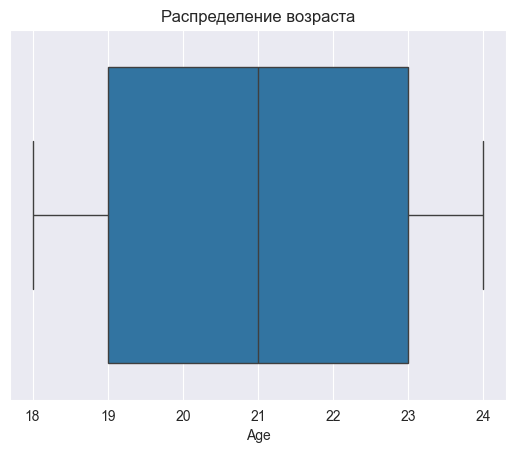

In [56]:
sns.boxplot(x=df['Age'])
plt.title("Распределение возраста")
plt.show()

Нулевое количество часов учебы выглялит странно для студента, скорее всего здесь 0 обозначает отсутствие данных

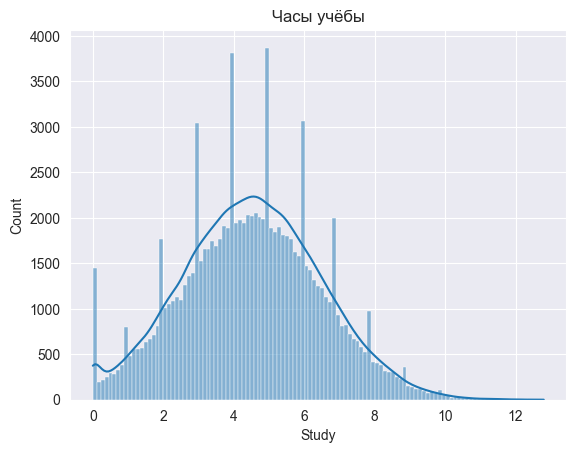

In [57]:
sns.histplot(df['Study'], kde=True)
plt.title("Часы учёбы")
plt.show()

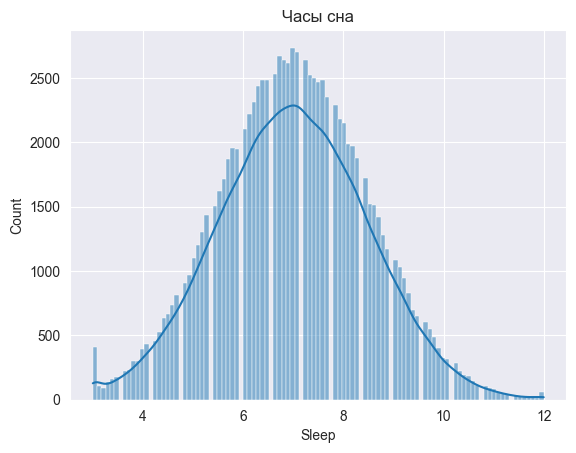

In [58]:
sns.histplot(df['Sleep'], kde=True)
plt.title("Часы сна")
plt.show()

Нулевое кол-во часов, проведенных в соц сетях (причем в нуле можно наблюдать резкий рост графика) довольно странно, возмодно это означает отсутствие данных.

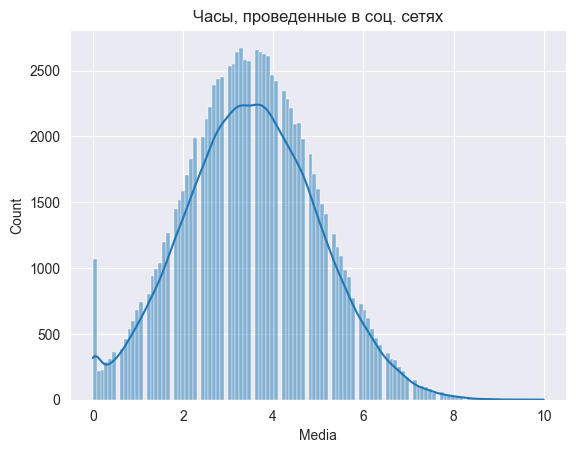

In [59]:
sns.histplot(df['Media'], kde=True)
plt.title("Часы, проведенные в соц. сетях")
plt.show()

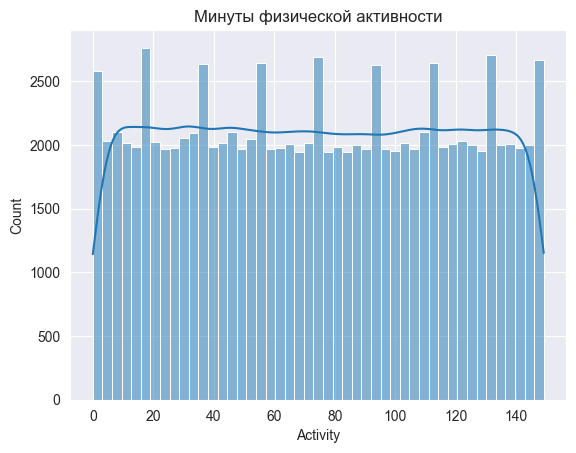

In [12]:
sns.histplot(df['Activity'], kde=True)
plt.title("Минуты физической активности")
plt.show()

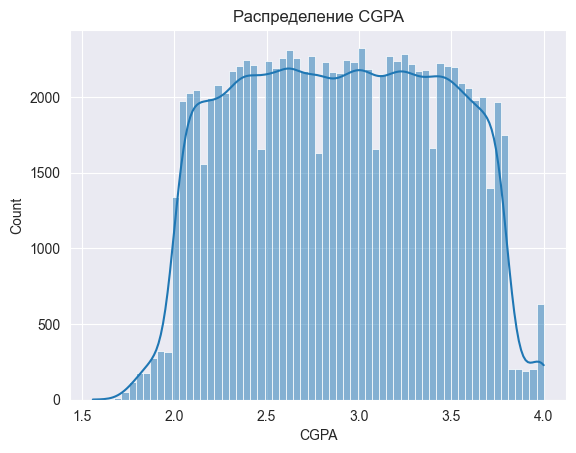

In [13]:
sns.histplot(df['CGPA'], kde=True)
plt.title("Распределение CGPA")
plt.show()

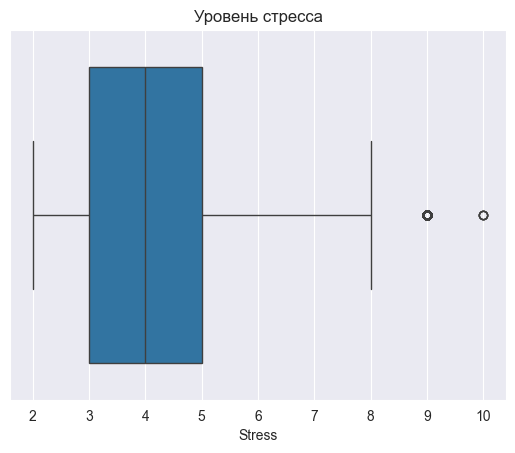

In [14]:
sns.boxplot(x=df['Stress'])
plt.title("Уровень стресса")
plt.show()

Как можно заметить по графику корреляции числовых признаков, корреляции нигде не наблюдается, что может мешать обучению модели

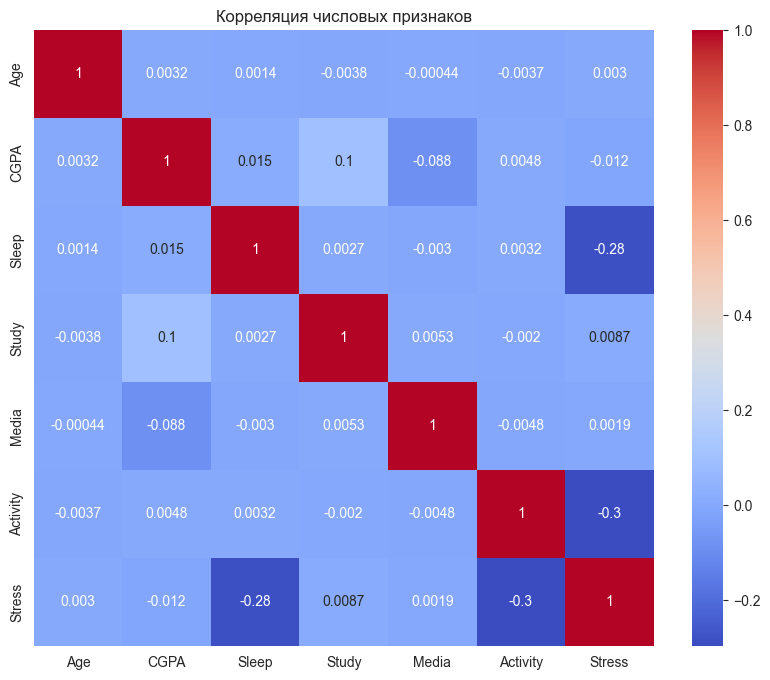

In [60]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number']).drop("Student_ID", axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()

# Удаление столбцов

Я приняла решение удалить столбец Age, так как проверила,что возраст всех опрашиваемых от 18 до 24. Выбросов нет, возраст находится в узком диапозонее значений и потенциально не может влиять на стиль жизни, уровень стресса и наличие депрессии.

In [61]:
df = df.drop('Age', axis=1)

Удаляю столбец с id студента, тк он не несет никакой информации о студенте, не связан с другими признаками, не помогает модели и даже может внести шум.

In [62]:
df = df.drop('Student_ID', axis=1)

# Поиск выбросов и дисбаланса классов

Отношение True/False ~ 1:9 => дисбаланс классов, плохо для обучения модели, модель может научиться отвечать, что депрессии нет

In [63]:
print(df['Depression'].value_counts())

Depression
False    89938
True     10062
Name: count, dtype: int64


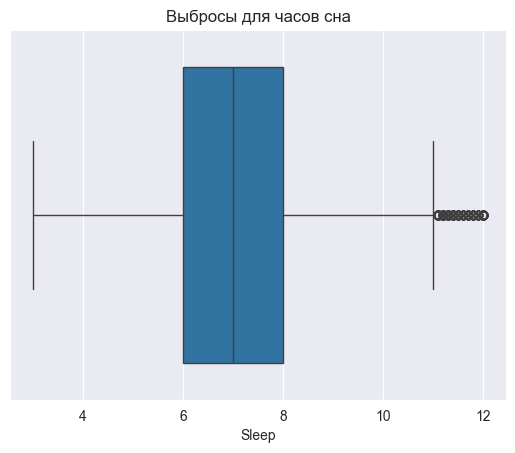

In [19]:
sns.boxplot(x=df['Sleep'])
plt.title("Выбросы для часов сна")
plt.show()

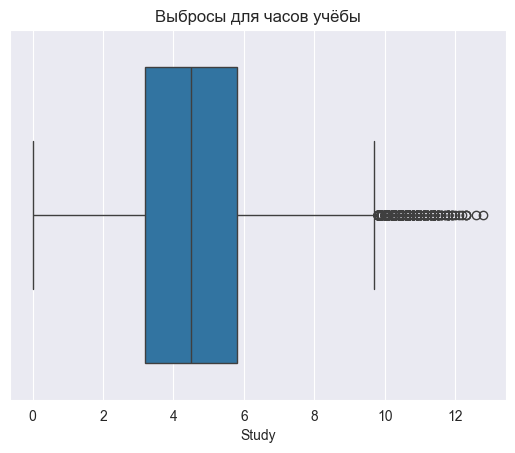

In [21]:
sns.boxplot(x=df['Study'])
plt.title("Выбросы для часов учёбы")
plt.show()

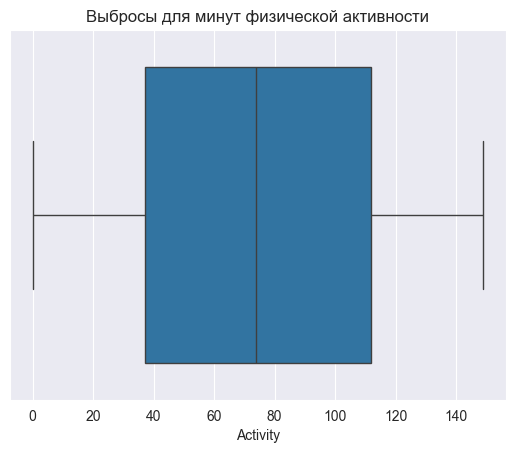

In [22]:
sns.boxplot(x=df['Activity'])
plt.title("Выбросы для минут физической активности")
plt.show()

# Обработка нулей

Заменяем выше описанные нули в Study и Media на медиану (она устойчива к выбросам, не смещает распределение, подходит для синтетических данных)

In [64]:
df['Study'] = df['Study'].replace(0, df['Study'].median())
df['Media'] = df['Media'].replace(0, df['Media'].median())

# Удаление дубликатов

In [66]:
df = df.drop_duplicates()
df.shape

(100000, 9)

получается, дубликатов нет

# One-Hot Encoding

Превращение текстовых данных в числовые столбцы (для Gender и Department) тк модель машинного обучения не умеет работать со строками

In [67]:
df = pd.get_dummies(df, columns=['Gender', 'Department'], drop_first=True)

In [68]:
df.columns

Index(['CGPA', 'Sleep', 'Study', 'Media', 'Activity', 'Stress', 'Depression',
       'Gender_Male', 'Department_Business', 'Department_Engineering',
       'Department_Medical', 'Department_Science'],
      dtype='str')

In [69]:
df.shape

(100000, 12)

# Масштабирование

In [70]:
X = df.drop(columns=['CGPA', 'Depression'])

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['Study', 'Sleep']]
y = df['CGPA']

# Разделение
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42, shuffle=True
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение модели

In [72]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_val_pred = model.predict(X_val_scaled)

# Оценка качества модели

In [74]:
def evaluate_model(y_true, y_pred, dataset="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100


    return f'Датасет: {dataset}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, MAPE: {mape}\n'

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
val_metrics = evaluate_model(y_val, y_val_pred, "Val")
print(train_metrics, test_metrics, val_metrics)

Датасет: Train, MAE: 0.45549411683558844, RMSE: 0.52906350146938, R2: 0.011386530947438689, MAPE: 16.594224365724493
 Датасет: Test, MAE: 0.4595816695063733, RMSE: 0.5333497939425347, R2: 0.007505123152157789, MAPE: 16.71131992326523
 Датасет: Val, MAE: 0.45267228420973527, RMSE: 0.5278042011580669, R2: 0.007962993016581987, MAPE: 16.44773652920971



В рамках задания была обучена модель линейной регрессии для прогнозирования успеваемости студента только на основе его режима занятий и сна, как указано в условии. Для корректной оценки качества данные были разделены на три выборки: обучающую (80%), валидационную (10%) и тестовую (10%), при этом масштабирование признаков выполнялось исключительно по обучающей выборке, что исключает утечку данных.

Результаты на всех трёх выборках оказались практически одинаковыми:
MAE ~ 0.45, RMSE ~ 0.53, MAPE ~ 16–17%, R² ~ 0.01.
Близость метрик Train, Val и Test показывает, что модель не переобучена и ведёт себя стабильно.

Однако значение R2 около 0.01 говорит о том, что модель объясняет лишь около 1% вариации целевой переменной. Это означает, что CGPA практически не зависит от количества часов сна и занятий, и линейная регрессия на этих признаках не способна построить качественный прогноз.

Таким образом, модель линейной регрессии получилась стабильной, но слабой по качеству - и это отражает ограниченность исходных признаков, а не ошибки в методологии.

# Feature Engineering

Гипотеза 1: нелинейность - квадрат часов учёбы

Гипотеза 2: отклонение сна от нормы.
Слишком мало и слишком много - оба случая плохи для успеваемости

In [75]:
df['Study_sq'] = df['Study'] ** 2

df['Sleep_deviation'] = (df['Sleep'] - 7.5).abs()

print(df[['Study_sq','Sleep_deviation','CGPA']].corr()['CGPA'])

Study_sq           0.120939
Sleep_deviation   -0.018736
CGPA               1.000000
Name: CGPA, dtype: float64


In [76]:
X = df[['Study', 'Study_sq', 'Sleep', 'Sleep_deviation']]
y = df['CGPA']

# Разделение
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42, shuffle=True
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение модели после Feature Engineering

In [77]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_val_pred = model.predict(X_val_scaled)

# Оценка ккачества модели после Feature Engineering

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np


def evaluate_model(y_true, y_pred, dataset="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return f'Датасет: {dataset}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, MAPE: {mape}\n'


train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
val_metrics = evaluate_model(y_val, y_val_pred, "Val")
print(train_metrics, test_metrics, val_metrics)

Датасет: Train, MAE: 0.45435937329048, RMSE: 0.5272364180015255, R2: 0.018202954273950356, MAPE: 16.549366823837463
 Датасет: Test, MAE: 0.45817260959925316, RMSE: 0.5312003966301219, R2: 0.015488504112063484, MAPE: 16.654580108862795
 Датасет: Val, MAE: 0.45067823952498115, RMSE: 0.5249356425217906, R2: 0.018716917436823577, MAPE: 16.369088488090867



Feature engineering удвоил R2, что подтверждает нелинейный характер зависимости. Тем не менее абсолютное значение остаётся низким - данные объективно не позволяют точно предсказать CGPA по режиму дня.

# Логистическая регрессия

In [100]:
class LogisticRegressionCustom:
    """
    Логистическая регрессия с градиентным спуском.
    Функция активации: Сигмоида
    Функция потерь: Binary Cross-Entropy (Log Loss) с весами классов
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba, sample_weights):
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
        return -np.mean(sample_weights * (y_true * np.log(y_pred_proba) +
                                          (1 - y_true) * np.log(1 - y_pred_proba)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        self.loss_history = []

        # Веса классов — компенсируем дисбаланс 90%/10%
        n0, n1 = np.sum(y == 0), np.sum(y == 1)
        sample_weights = np.where(y == 1, n_samples / (2 * n1), n_samples / (2 * n0))

        for epoch in range(self.n_iterations):
            # Прямой проход
            y_pred_proba = self._sigmoid(np.dot(X, self.weights) + self.bias)
            # Функция потерь
            loss = self._compute_loss(y, y_pred_proba, sample_weights)
            self.loss_history.append(loss)
            # Градиенты
            error = (y_pred_proba - y) * sample_weights
            dw = np.dot(X.T, error) / n_samples
            db = np.sum(error) / n_samples
            # Обновление весов
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db
        return self

    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.weights) + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [101]:
feature_cols = ['Study', 'Sleep', 'Media', 'Activity', 'Stress']
X = df[feature_cols].values
y = df['Depression'].astype(int).values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train)
X_val_scaled   = scaler_cls.transform(X_val)
X_test_scaled  = scaler_cls.transform(X_test)

print(f"Train: {X_train_scaled.shape[0]}, Val: {X_val_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")
print(f"Доля депрессии в train: {y_train.mean():.3f}")

Train: 80010, Val: 9990, Test: 10000
Доля депрессии в train: 0.101


In [102]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

learning_rates = [0.001, 0.01, 0.1]
epochs_list    = [50, 100, 200]
results = []

for lr in learning_rates:
    for ep in epochs_list:
        m = LogisticRegressionCustom(learning_rate=lr, n_iterations=ep)
        m.fit(X_train_scaled, y_train)
        val_pred = m.predict(X_val_scaled)
        results.append({
            'lr': lr, 'epochs': ep,
            'val_f1':  f1_score(y_val, val_pred),
            'val_acc': accuracy_score(y_val, val_pred),
            'val_auc': roc_auc_score(y_val, m.predict_proba(X_val_scaled))
        })

results_df = pd.DataFrame(results)
print("F1 на валидации по комбинациям lr/epochs:")
print(results_df.pivot(index='epochs', columns='lr', values='val_f1').round(3))

best = results_df.loc[results_df['val_f1'].idxmax()]
print(f"\nЛучшие параметры: lr={best['lr']}, epochs={int(best['epochs'])}, F1={best['val_f1']:.3f}")

F1 на валидации по комбинациям lr/epochs:
lr      0.001  0.010  0.100
epochs                     
50      0.161  0.185  0.184
100     0.174  0.183  0.181
200     0.183  0.182  0.182

Лучшие параметры: lr=0.01, epochs=50, F1=0.185


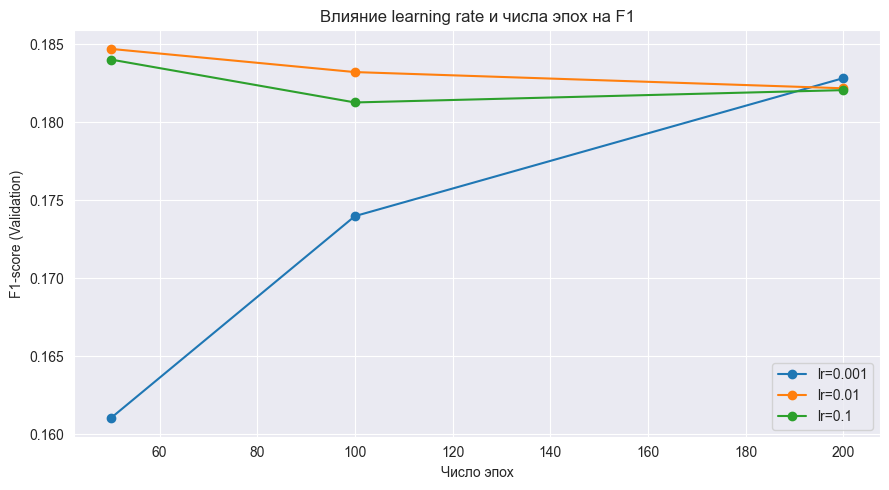

In [103]:
fig, ax = plt.subplots(figsize=(9, 5))
for lr in learning_rates:
    subset = results_df[results_df['lr'] == lr]
    ax.plot(subset['epochs'], subset['val_f1'], marker='o', label=f'lr={lr}')
ax.set_xlabel('Число эпох')
ax.set_ylabel('F1-score (Validation)')
ax.set_title('Влияние learning rate и числа эпох на F1')
ax.legend()
plt.tight_layout()
plt.show()

In [104]:
best_model = LogisticRegressionCustom(
    learning_rate=best['lr'], n_iterations=int(best['epochs']))
best_model.fit(X_train_scaled, y_train)

y_train_pred  = best_model.predict(X_train_scaled)
y_test_pred   = best_model.predict(X_test_scaled)
y_val_pred    = best_model.predict(X_val_scaled)
y_test_proba  = best_model.predict_proba(X_test_scaled)
y_train_proba = best_model.predict_proba(X_train_scaled)
y_val_proba   = best_model.predict_proba(X_val_scaled)

def evaluate_classification(y_true, y_pred, y_proba=None, name="Dataset"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    print(f"\nМетрики для {name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc: print(f"  AUC-ROC:   {auc:.4f}")
    return {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1,'AUC-ROC':auc}

train_metrics = evaluate_classification(y_train, y_train_pred, y_train_proba, "Train")
test_metrics  = evaluate_classification(y_test,  y_test_pred,  y_test_proba,  "Test")
val_metrics   = evaluate_classification(y_val,   y_val_pred,   y_val_proba,   "Val")


Метрики для Train:
  Accuracy:  0.5449
  Precision: 0.1135
  Recall:    0.5172
  F1-Score:  0.1861
  AUC-ROC:   0.5559

Метрики для Test:
  Accuracy:  0.5408
  Precision: 0.1164
  Recall:    0.5408
  F1-Score:  0.1915
  AUC-ROC:   0.5670

Метрики для Val:
  Accuracy:  0.5422
  Precision: 0.1125
  Recall:    0.5154
  F1-Score:  0.1847
  AUC-ROC:   0.5504


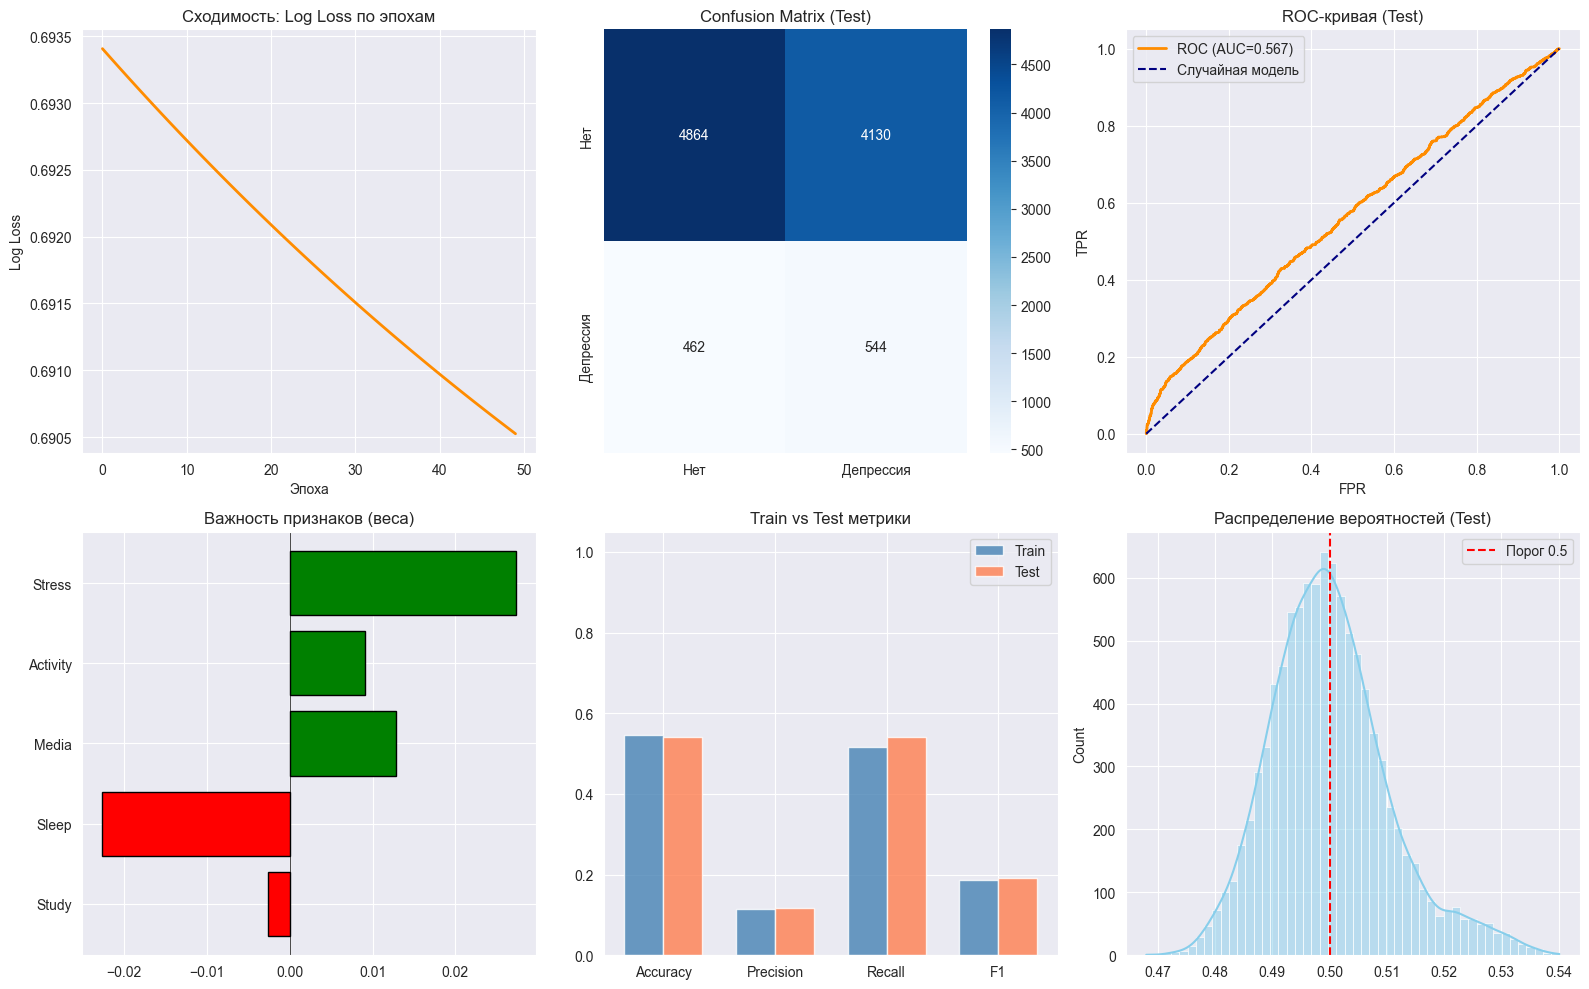

In [85]:
fig = plt.figure(figsize=(16, 10))

# Loss по эпохам
ax1 = plt.subplot(2, 3, 1)
ax1.plot(best_model.loss_history, color='darkorange', linewidth=2)
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Log Loss')
ax1.set_title('Сходимость: Log Loss по эпохам')

# Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Нет','Депрессия'], yticklabels=['Нет','Депрессия'])
ax2.set_title('Confusion Matrix (Test)')

# ROC-кривая
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC (AUC={test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0,1],[0,1], 'navy', linestyle='--', label='Случайная модель')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title('ROC-кривая (Test)'); ax3.legend()

# Веса признаков
ax4 = plt.subplot(2, 3, 4)
colors = ['green' if w > 0 else 'red' for w in best_model.weights]
ax4.barh(feature_cols, best_model.weights, color=colors, edgecolor='black')
ax4.axvline(0, color='black', lw=0.5)
ax4.set_title('Важность признаков (веса)')

# Train vs Test метрики
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy','Precision','Recall','F1']
x = np.arange(len(metrics_names)); w = 0.35
ax5.bar(x-w/2, [train_metrics[m] for m in metrics_names], w, label='Train', color='steelblue', alpha=0.8)
ax5.bar(x+w/2, [test_metrics[m]  for m in metrics_names], w, label='Test',  color='coral',    alpha=0.8)
ax5.set_xticks(x); ax5.set_xticklabels(metrics_names)
ax5.set_ylim(0, 1.05); ax5.legend()
ax5.set_title('Train vs Test метрики')

# Распределение вероятностей
ax6 = plt.subplot(2, 3, 6)
sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue')
ax6.axvline(0.5, color='red', linestyle='--', label='Порог 0.5')
ax6.set_title('Распределение вероятностей (Test)')
ax6.legend()

plt.tight_layout()
plt.show()

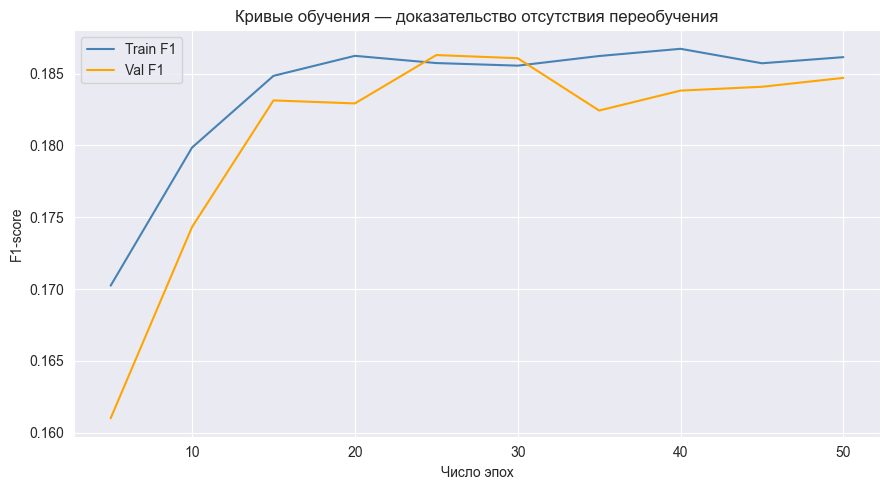

Train F1: 0.1861
Val F1:   0.1847
Разница:  0.0014 — переобучения нет


In [86]:
epochs_range = list(range(5, int(best['epochs'])+1, 5))
train_f1s, val_f1s = [], []

for ep in epochs_range:
    m = LogisticRegressionCustom(learning_rate=best['lr'], n_iterations=ep)
    m.fit(X_train_scaled, y_train)
    train_f1s.append(f1_score(y_train, m.predict(X_train_scaled)))
    val_f1s.append(f1_score(y_val,   m.predict(X_val_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_f1s, label='Train F1', color='steelblue')
plt.plot(epochs_range, val_f1s,   label='Val F1',   color='orange')
plt.xlabel('Число эпох'); plt.ylabel('F1-score')
plt.title('Кривые обучения — доказательство отсутствия переобучения')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Train F1: {train_f1s[-1]:.4f}")
print(f"Val F1:   {val_f1s[-1]:.4f}")
print(f"Разница:  {abs(train_f1s[-1]-val_f1s[-1]):.4f} — {'переобучения нет' if abs(train_f1s[-1]-val_f1s[-1]) < 0.05 else 'возможное переобучение'}")

# Feature Engineering

In [89]:
from sklearn.utils import resample

df_majority = df[df['Depression'] == 0]
df_minority = df[df['Depression'] == 1]

df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced['Stress_squared'] = df_balanced['Stress'] ** 2
df_balanced['Sleep_deviation'] = abs(df_balanced['Sleep'] - 7.5)

In [90]:
X = df_balanced[['Study', 'Sleep', 'Stress', 'Stress_squared', 'Sleep_deviation']]
y = df_balanced['Depression']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train)
X_val_scaled   = scaler_cls.transform(X_val)
X_test_scaled  = scaler_cls.transform(X_test)

print(f"Train: {X_train_scaled.shape[0]}, Val: {X_val_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")
print(f"Доля депрессии в train: {y_train.mean():.3f}")

Train: 16100, Val: 2011, Test: 2013
Доля депрессии в train: 0.500


In [91]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

learning_rates = [0.001, 0.01, 0.1]
epochs_list    = [50, 100, 200]
results = []

for lr in learning_rates:
    for ep in epochs_list:
        m = LogisticRegressionCustom(learning_rate=lr, n_iterations=ep)
        m.fit(X_train_scaled, y_train)
        val_pred = m.predict(X_val_scaled)
        results.append({
            'lr': lr, 'epochs': ep,
            'val_f1':  f1_score(y_val, val_pred),
            'val_acc': accuracy_score(y_val, val_pred),
            'val_auc': roc_auc_score(y_val, m.predict_proba(X_val_scaled))
        })

results_df = pd.DataFrame(results)
print("F1 на валидации по комбинациям lr/epochs:")
print(results_df.pivot(index='epochs', columns='lr', values='val_f1').round(3))

best = results_df.loc[results_df['val_f1'].idxmax()]
print(f"\nЛучшие параметры: lr={best['lr']}, epochs={int(best['epochs'])}, F1={best['val_f1']:.3f}")

F1 на валидации по комбинациям lr/epochs:
lr      0.001  0.010  0.100
epochs                     
50      0.495  0.493  0.486
100     0.501  0.482  0.489
200     0.509  0.482  0.486

Лучшие параметры: lr=0.001, epochs=200, F1=0.509


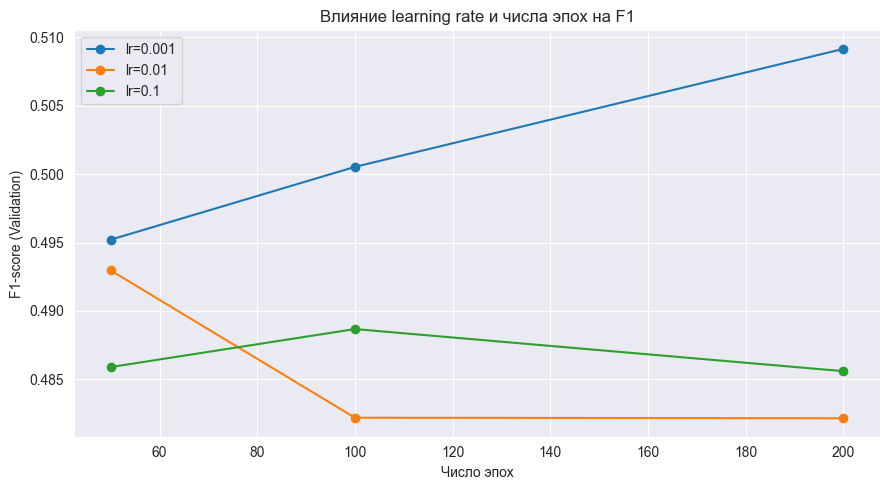

In [92]:
fig, ax = plt.subplots(figsize=(9, 5))
for lr in learning_rates:
    subset = results_df[results_df['lr'] == lr]
    ax.plot(subset['epochs'], subset['val_f1'], marker='o', label=f'lr={lr}')
ax.set_xlabel('Число эпох')
ax.set_ylabel('F1-score (Validation)')
ax.set_title('Влияние learning rate и числа эпох на F1')
ax.legend()
plt.tight_layout()
plt.show()

In [96]:
best_model = LogisticRegressionCustom(
    learning_rate=best['lr'], n_iterations=int(best['epochs']))
best_model.fit(X_train_scaled, y_train)

y_train_pred  = best_model.predict(X_train_scaled)
y_test_pred   = best_model.predict(X_test_scaled)
y_val_pred    = best_model.predict(X_val_scaled)
y_test_proba  = best_model.predict_proba(X_test_scaled)
y_train_proba = best_model.predict_proba(X_train_scaled)
y_val_proba   = best_model.predict_proba(X_val_scaled)

def evaluate_classification(y_true, y_pred, y_proba=None, name="Dataset"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    print(f"\nМетрики для {name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc: print(f"  AUC-ROC:   {auc:.4f}")
    return {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1,'AUC-ROC':auc}

train_metrics = evaluate_classification(y_train, y_train_pred, y_train_proba, "Train")
test_metrics  = evaluate_classification(y_test,  y_test_pred,  y_test_proba,  "Test")
val_metrics   = evaluate_classification(y_val,   y_val_pred,   y_val_proba,   "Val")


Метрики для Train:
  Accuracy:  0.5297
  Precision: 0.5328
  Recall:    0.4819
  F1-Score:  0.5061
  AUC-ROC:   0.5496

Метрики для Test:
  Accuracy:  0.5246
  Precision: 0.5255
  Recall:    0.5010
  F1-Score:  0.5130
  AUC-ROC:   0.5443

Метрики для Val:
  Accuracy:  0.5341
  Precision: 0.5382
  Recall:    0.4831
  F1-Score:  0.5092
  AUC-ROC:   0.5557


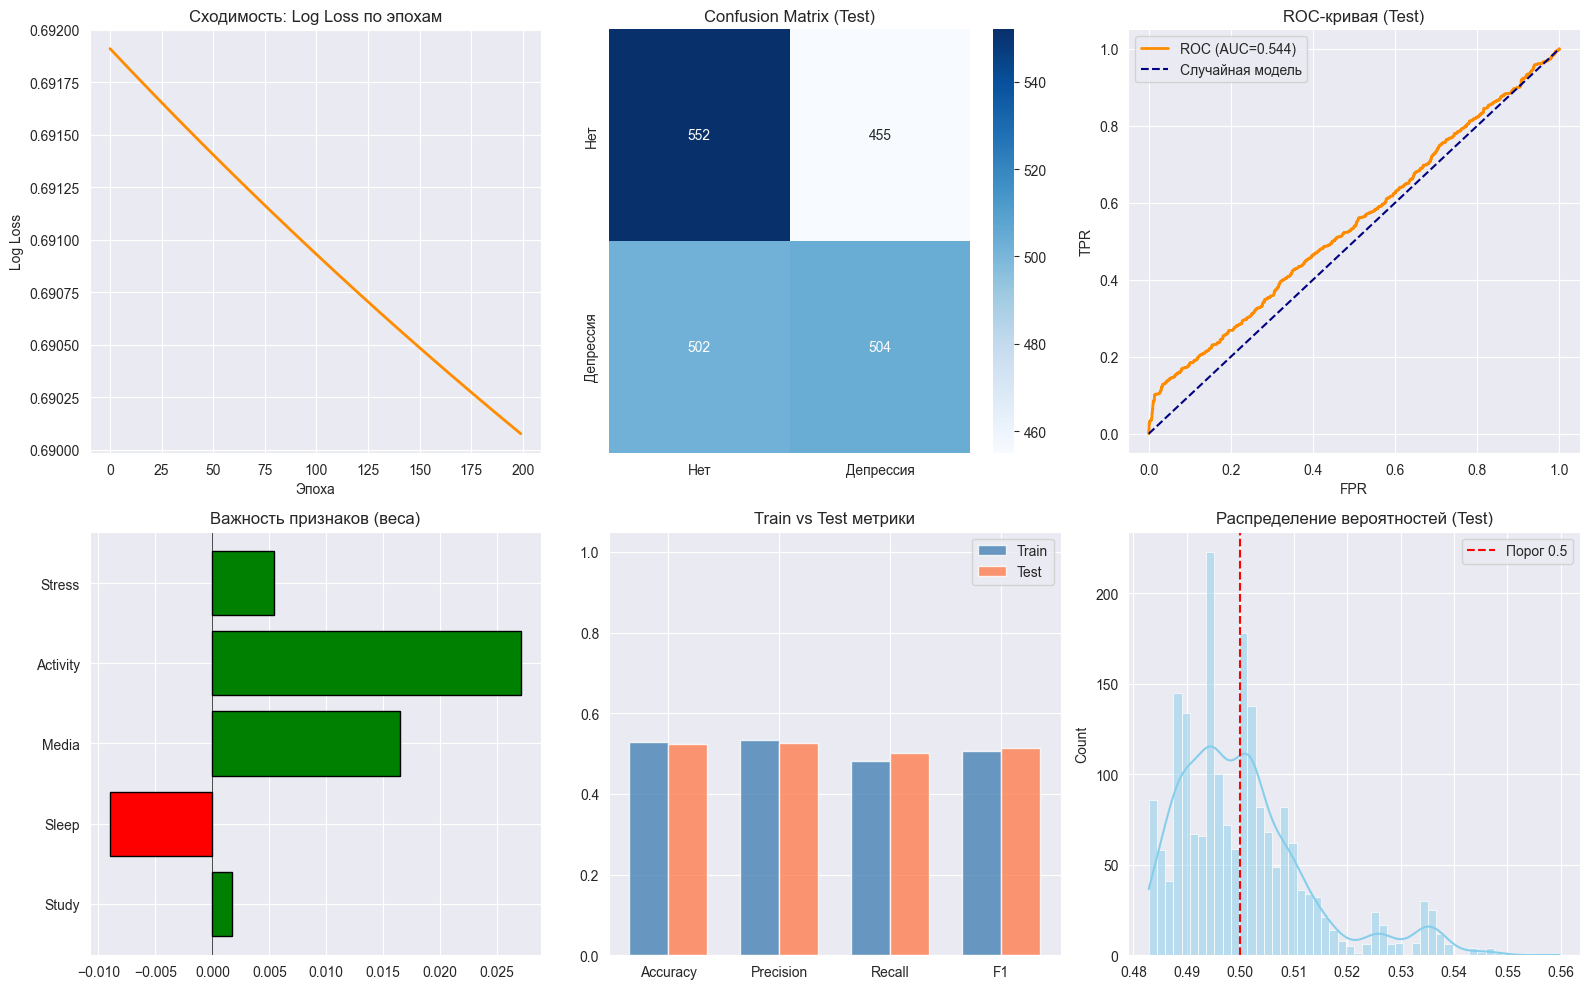

In [97]:
fig = plt.figure(figsize=(16, 10))

# Loss по эпохам
ax1 = plt.subplot(2, 3, 1)
ax1.plot(best_model.loss_history, color='darkorange', linewidth=2)
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Log Loss')
ax1.set_title('Сходимость: Log Loss по эпохам')

# Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Нет','Депрессия'], yticklabels=['Нет','Депрессия'])
ax2.set_title('Confusion Matrix (Test)')

# ROC-кривая
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC (AUC={test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0,1],[0,1], 'navy', linestyle='--', label='Случайная модель')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title('ROC-кривая (Test)'); ax3.legend()

# Веса признаков
ax4 = plt.subplot(2, 3, 4)
colors = ['green' if w > 0 else 'red' for w in best_model.weights]
ax4.barh(feature_cols, best_model.weights, color=colors, edgecolor='black')
ax4.axvline(0, color='black', lw=0.5)
ax4.set_title('Важность признаков (веса)')

# Train vs Test метрики
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy','Precision','Recall','F1']
x = np.arange(len(metrics_names)); w = 0.35
ax5.bar(x-w/2, [train_metrics[m] for m in metrics_names], w, label='Train', color='steelblue', alpha=0.8)
ax5.bar(x+w/2, [test_metrics[m]  for m in metrics_names], w, label='Test',  color='coral',    alpha=0.8)
ax5.set_xticks(x); ax5.set_xticklabels(metrics_names)
ax5.set_ylim(0, 1.05); ax5.legend()
ax5.set_title('Train vs Test метрики')

# Распределение вероятностей
ax6 = plt.subplot(2, 3, 6)
sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue')
ax6.axvline(0.5, color='red', linestyle='--', label='Порог 0.5')
ax6.set_title('Распределение вероятностей (Test)')
ax6.legend()

plt.tight_layout()
plt.show()

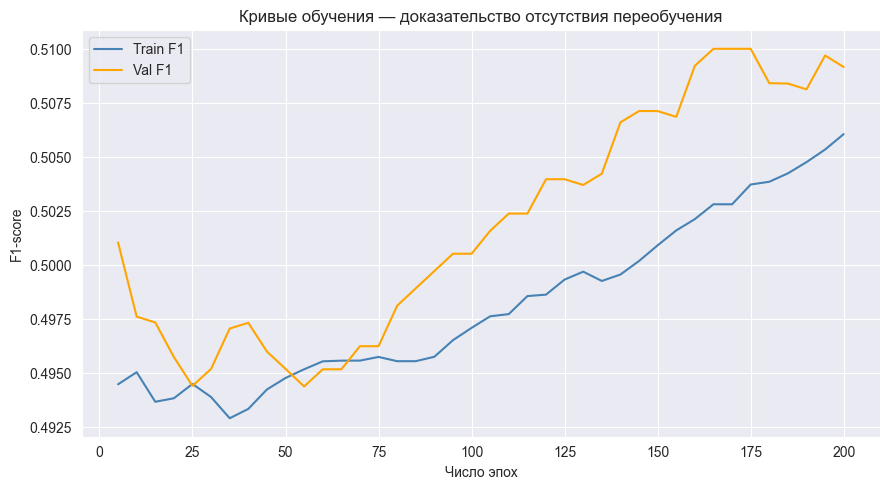

Train F1: 0.5061
Val F1:   0.5092
Разница:  0.0031 — переобучения нет


In [98]:
epochs_range = list(range(5, int(best['epochs'])+1, 5))
train_f1s, val_f1s = [], []

for ep in epochs_range:
    m = LogisticRegressionCustom(learning_rate=best['lr'], n_iterations=ep)
    m.fit(X_train_scaled, y_train)
    train_f1s.append(f1_score(y_train, m.predict(X_train_scaled)))
    val_f1s.append(f1_score(y_val,   m.predict(X_val_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_f1s, label='Train F1', color='steelblue')
plt.plot(epochs_range, val_f1s,   label='Val F1',   color='orange')
plt.xlabel('Число эпох'); plt.ylabel('F1-score')
plt.title('Кривые обучения — доказательство отсутствия переобучения')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Train F1: {train_f1s[-1]:.4f}")
print(f"Val F1:   {val_f1s[-1]:.4f}")
print(f"Разница:  {abs(train_f1s[-1]-val_f1s[-1]):.4f} — {'переобучения нет' if abs(train_f1s[-1]-val_f1s[-1]) < 0.05 else 'возможное переобучение'}")